# Reproduce Figure 2
Sink levels (lstart, lifetime) in different models.

You need 1 file:
- `sink_detection_info_path`: sink detection results from `./src/hidden_state_base.py`.

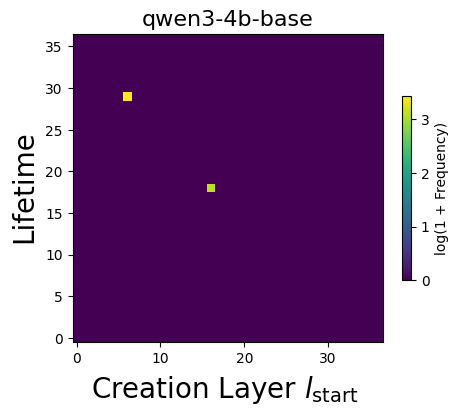

In [34]:
from src.utils import MODEL_DICT
from transformers import AutoConfig
from collections import Counter
from matplotlib import pyplot as plt
import os
from matplotlib import cm
import torch
import math
import json

def hierarchical_heatmap_plot(hierarchical_map, model_short_name, ax):
    max_layer = AutoConfig.from_pretrained(
        MODEL_DICT.get(model_short_name, model_short_name)
    ).num_hidden_layers

    heatmap_data = torch.zeros(max_layer + 1, max_layer + 1)

    for level, sink_layers_info in hierarchical_map.items():
        for layers in sink_layers_info:
            creation_layer = layers[0]
            if level <= max_layer and creation_layer <= max_layer:
                heatmap_data[level, creation_layer] += 1

    heatmap_data_log_scaled = torch.log1p(heatmap_data)

    im = ax.imshow(
        heatmap_data_log_scaled.numpy(),
        cmap="viridis",
        aspect="auto"
    )
    ax.invert_yaxis()
    ax.set_title(model_short_name, fontsize=16)

    return im

def analyze_sink_info(sink_info_path):

    model_names = ["qwen3-4b-base"]
    model_names = [
        m for m in os.listdir(sink_info_path)
    ]
    # NOTE: If you want to visualize more models, you can just add them to the list below. For example:
    # model_names += ['qwen2.5-32b', 'qwen2.5-32b-instruct']

    num_models = len(model_names)
    cols = 4
    rows = math.ceil(num_models / cols)

    if num_models == 1:
        rows, cols = 1, 1
        
    fig, axes = plt.subplots(
        rows, cols,
        figsize=(cols * 5, rows * 4),
        squeeze=False
    )

    last_im = None

    for idx, model_short_name in enumerate(model_names):
        row, col = divmod(idx, cols)
        ax = axes[row][col]

        dir_path = os.path.join(sink_info_path, model_short_name)
        hierarchical_map = {}

        for file in os.listdir(dir_path):
            if file.endswith(".jsonl"):
                with open(os.path.join(dir_path, file), "r") as f:
                    for line in f:
                        data = json.loads(line)["candidate_sinks"]
                        for _, info in data.items():
                            level = len(info["layer"])
                            hierarchical_map.setdefault(level, []).append(info["layer"])

        last_im = hierarchical_heatmap_plot(
            hierarchical_map,
            model_short_name,
            ax
        )

    # Turn off empty subplots
    for i in range(num_models, rows * cols):
        r, c = divmod(i, cols)
        axes[r][c].axis("off")

    # Shared colorbar
    cbar = fig.colorbar(
        last_im,
        ax=axes.ravel().tolist(),
        shrink=0.6,
        label="log(1 + Frequency)"
    )

    # NOTE: Adjust the position of the shared x and y labels as needed. The values below are just examples.
    fig.supxlabel(r"Creation Layer $l_\text{start}$", fontsize=20, y=-0.05, x=0.43)
    fig.supylabel("Lifetime", fontsize=20, x=0)
    plt.savefig(sink_info_path / "life_time_vs_creation_layer_across_models.pdf", dpi=300, bbox_inches='tight')
    print(f"Saved heatmap to {sink_info_path / 'life_time_vs_creation_layer_across_models.pdf'}")
    plt.show()


from pathlib import Path
sink_info_path = Path("./results/sink_detection")
analyze_sink_info(sink_info_path)
